In [4]:
# %%
"""
Planogram Generation Model — Approach 1: Retrieval + Gap-Fill

Given a store's product assortment and shelf layout, finds the closest
historic planogram and adapts it by swapping unavailable products with
the most similar available ones.
"""

import pandas as pd
import numpy as np
from dataclasses import dataclass, field
from collections import defaultdict
from copy import deepcopy

# Import from exploracion.py
from exploracion import (
    load_planograms,
    Planogram,
    Shelf,
    ProductPlacement,
)


# =============================================================
# PRODUCT CATALOG
# =============================================================

@dataclass
class ProductInfo:
    """Static product properties (from the catalog)."""
    upc: str
    description: str
    width: float     # ANCHO (cm)
    height: float    # ALTO (cm)


def build_product_catalog(csv_path: str) -> dict[str, ProductInfo]:
    """
    Build a catalog of all known products with their dimensions.
    Returns {upc: ProductInfo}.
    """
    from exploracion import normalize_column

    df = pd.read_csv(csv_path, encoding='latin-1')
    df.columns = [normalize_column(c) for c in df.columns]

    catalog = {}
    for _, row in df.iterrows():
        upc = str(row['UPC_CVE'])
        if upc not in catalog:
            catalog[upc] = ProductInfo(
                upc=upc,
                description=str(row.get('ITEM_DESC', upc)),
                width=float(row['ANCHO']),
                height=float(row['ALTO']),
            )

    return catalog


# =============================================================
# MATCHING — Find Best Historic Planogram
# =============================================================

def find_best_match(
    target_upcs: set[str],
    target_tamano: float,
    historic_planograms: list[Planogram],
    exclude_keys: set = None,
) -> tuple[Planogram, int, int]:
    """
    Find the historic planogram with the most product overlap.

    Filters by compatible shelf layout (same tamaño), then counts
    how many products in each historic planogram are also in the
    target assortment. Returns the best match.

    Parameters
    ----------
    target_upcs : set of UPC strings available at the target store
    target_tamano : shelf layout size (3, 3.5, 4, 4.5, 5)
    historic_planograms : list of all loaded Planogram objects
    exclude_keys : planogram keys to exclude (for leave-one-out eval)

    Returns
    -------
    (best_planogram, n_matches, n_template_products)
    """
    best_match = None
    best_overlap = -1
    best_total = 0

    for plano in historic_planograms:

        # Skip excluded planograms (for leave-one-out evaluation)
        if exclude_keys and plano.key in exclude_keys:
            continue

        # Filter: must have compatible shelf layout
        if plano.tamano != target_tamano:
            continue

        # Collect all unique UPCs in this planogram
        template_upcs = set()
        for shelf in plano.shelves.values():
            for product in shelf.products:
                template_upcs.add(product.upc)

        # Count how many template products are available
        overlap = len(template_upcs & target_upcs)

        if overlap > best_overlap:
            best_overlap = overlap
            best_match = plano
            best_total = len(template_upcs)

    return best_match, best_overlap, best_total


# =============================================================
# PRODUCT SUBSTITUTION — Find Closest Available Product
# =============================================================

def find_closest_product(
    original: ProductInfo,
    available_upcs: set[str],
    catalog: dict[str, ProductInfo],
    already_used: set[str] = None,
) -> str | None:
    """
    Find the available product most similar to the original.

    Similarity is based on physical dimensions (width and height),
    since products of similar size tend to be in the same category
    (e.g., 2.5L bottles, 600ml bottles, 355ml cans).

    Parameters
    ----------
    original : ProductInfo of the product to replace
    available_upcs : set of UPCs available at the target store
    catalog : full product catalog
    already_used : UPCs already placed (to avoid duplicates)

    Returns
    -------
    UPC of the closest available product, or None if nothing fits.
    """
    if already_used is None:
        already_used = set()

    candidates = available_upcs - already_used
    if not candidates:
        return None

    best_upc = None
    best_distance = float('inf')

    for upc in candidates:
        if upc not in catalog:
            continue

        candidate = catalog[upc]

        # Distance: weighted combination of width and height difference
        # Height is more important (determines shelf level placement)
        d_width = abs(candidate.width - original.width)
        d_height = abs(candidate.height - original.height)
        distance = d_width + 2.0 * d_height

        if distance < best_distance:
            best_distance = distance
            best_upc = upc

    return best_upc


# =============================================================
# ADAPTATION — Adapt Template to Target Assortment
# =============================================================

def adapt_planogram(
    template: Planogram,
    target_upcs: set[str],
    catalog: dict[str, ProductInfo],
) -> Planogram:
    """
    Adapt a template planogram to a target store's assortment.

    1. Keep all products that are available in the target store.
    2. Replace unavailable products with the closest available
       product not yet placed.
    3. Any target products still unplaced are inserted into shelf
       gaps (shelves with remaining width capacity).

    Parameters
    ----------
    template : the best-matching historic planogram
    target_upcs : set of UPCs available at the target store
    catalog : product catalog with dimensions

    Returns
    -------
    A new Planogram object with adapted product placements.
    """
    # Deep copy so we don't modify the template
    result = Planogram(
        segmento_id=template.segmento_id,
        mueble_id=template.mueble_id,
        planogrupo=template.planogrupo,
        tamano=template.tamano,
        direccion=template.direccion,
        conjunto_id="GENERATED",
    )

    # Track which target products have been placed
    placed_upcs = set()

    # --- Phase 1: Copy available products, replace unavailable ones ---
    for charola_num, shelf in sorted(template.shelves.items()):

        new_shelf = Shelf(
            charola=shelf.charola,
            door=shelf.door,
            level=shelf.level,
            x=shelf.x,
            y=shelf.y,
            shelf_width=shelf.shelf_width,
            shelf_height=shelf.shelf_height,
        )

        for product in shelf.sorted_products():

            if product.upc in target_upcs:
                # Product is available — keep it
                new_product = ProductPlacement(
                    upc=product.upc,
                    description=product.description,
                    shelf=product.shelf,
                    position=product.position,
                    facings=product.facings,
                    width=product.width,
                    height=product.height,
                )
                new_shelf.products.append(new_product)
                placed_upcs.add(product.upc)

            else:
                # Product not available — find closest substitute
                original_info = catalog.get(product.upc)
                if original_info is None:
                    continue

                substitute_upc = find_closest_product(
                    original=original_info,
                    available_upcs=target_upcs,
                    catalog=catalog,
                    already_used=placed_upcs,
                )

                if substitute_upc and substitute_upc in catalog:
                    sub_info = catalog[substitute_upc]
                    new_product = ProductPlacement(
                        upc=substitute_upc,
                        description=sub_info.description,
                        shelf=product.shelf,
                        position=product.position,
                        facings=product.facings,
                        width=sub_info.width,
                        height=sub_info.height,
                    )
                    new_shelf.products.append(new_product)
                    placed_upcs.add(substitute_upc)

        result.shelves[charola_num] = new_shelf

    # --- Phase 2: Insert unplaced products into shelf gaps ---
    unplaced = target_upcs - placed_upcs

    if unplaced:
        # Sort unplaced by height (descending) to match level pattern:
        # tall products → lower levels (lower Y)
        unplaced_sorted = sorted(
            unplaced,
            key=lambda u: catalog[u].height if u in catalog else 0,
            reverse=True,
        )

        # Try to fit each unplaced product into a shelf with room
        for upc in unplaced_sorted:
            if upc not in catalog:
                continue

            prod_info = catalog[upc]
            best_shelf_num = None
            best_remaining = float('inf')

            # Find the shelf with the least remaining space that
            # still fits this product (best-fit decreasing)
            for charola_num, shelf in result.shelves.items():
                used_width = sum(
                    p.width * p.facings for p in shelf.products
                )
                remaining = shelf.shelf_width - used_width

                if remaining >= prod_info.width:
                    # Prefer shelves at matching height level
                    # (tall products → low Y, short → high Y)
                    height_penalty = abs(
                        shelf.y - _ideal_y_for_height(prod_info.height)
                    )
                    score = remaining + height_penalty * 0.1

                    if score < best_remaining:
                        best_remaining = score
                        best_shelf_num = charola_num

            if best_shelf_num is not None:
                shelf = result.shelves[best_shelf_num]
                max_pos = max(
                    (p.position for p in shelf.products), default=0
                )
                new_product = ProductPlacement(
                    upc=upc,
                    description=prod_info.description,
                    shelf=best_shelf_num,
                    position=max_pos + 1,
                    facings=1,
                    width=prod_info.width,
                    height=prod_info.height,
                )
                shelf.products.append(new_product)
                placed_upcs.add(upc)

    return result


def _ideal_y_for_height(product_height: float) -> float:
    """
    Estimate the ideal shelf Y coordinate for a product of given height.
    Based on the strong negative correlation (r=-0.90) observed in data:
      ALTO 30-40 → Y ≈ 20 (bottom)
      ALTO 25-30 → Y ≈ 90
      ALTO 20-25 → Y ≈ 130
      ALTO 15-20 → Y ≈ 166
      ALTO <15   → Y ≈ 168 (top)
    """
    if product_height >= 30:
        return 20.0
    elif product_height >= 25:
        return 90.0
    elif product_height >= 20:
        return 130.0
    elif product_height >= 15:
        return 166.0
    else:
        return 168.0


# =============================================================
# RULE MINING — Extract placement rules from ALL planograms
# =============================================================

def mine_placement_rules(
    planograms: list[Planogram],
    catalog: dict[str, ProductInfo],
) -> dict:
    """
    Mine implicit placement rules from all historic planograms.

    Returns a dict with:
      - 'level_probs': {upc: {level: probability}}
      - 'adjacencies': {(upc_a, upc_b): frequency}
      - 'height_level_corr': correlation between product height and level
    """
    level_counts = defaultdict(lambda: defaultdict(int))
    adjacencies = defaultdict(int)

    for plano in planograms:
        for shelf in plano.shelves.values():
            prods = shelf.sorted_products()

            # Level assignment
            for p in prods:
                level_counts[p.upc][shelf.level] += 1

            # Adjacencies (products on same shelf)
            upcs = [p.upc for p in prods]
            for i in range(len(upcs)):
                for j in range(i + 1, len(upcs)):
                    pair = tuple(sorted([upcs[i], upcs[j]]))
                    adjacencies[pair] += 1

    # Convert counts to probabilities
    level_probs = {}
    for upc, levels in level_counts.items():
        total = sum(levels.values())
        level_probs[upc] = {lv: cnt / total for lv, cnt in levels.items()}

    return {
        'level_probs': level_probs,
        'adjacencies': dict(adjacencies),
        'n_planograms': len(planograms),
    }


# =============================================================
# RULE-ADHERENCE EVALUATION
# =============================================================

def evaluate_rule_adherence(
    planogram: Planogram,
    rules: dict,
    catalog: dict[str, ProductInfo],
) -> dict:
    """
    Evaluate how well a planogram follows the placement rules
    mined from historic data. This does NOT require a ground-truth
    planogram — it measures rule compliance directly.

    Metrics:
      - level_rule_score: how often products are on their historically
        most common level (weighted by confidence)
      - adjacency_score: what fraction of observed adjacencies in this
        planogram also appear frequently in historic data
      - width_feasibility: fraction of shelves within width limits
      - height_ordering: whether taller products are on lower shelves
      - product_coverage: fraction of target products placed
    """
    metrics = {}
    level_probs = rules['level_probs']
    adjacencies = rules['adjacencies']

    # --- 1. Level Rule Score ---
    # For each product, how likely is its assigned level according
    # to the historic distribution?
    level_scores = []
    level_match_count = 0
    level_total = 0

    for shelf in planogram.shelves.values():
        for p in shelf.products:
            if p.upc in level_probs:
                prob = level_probs[p.upc].get(shelf.level, 0.0)
                level_scores.append(prob)
                # Also check if it's the most common level
                best_level = max(level_probs[p.upc],
                                 key=level_probs[p.upc].get)
                level_total += 1
                if shelf.level == best_level:
                    level_match_count += 1

    metrics['level_rule_score'] = (
        np.mean(level_scores) if level_scores else 0.0
    )
    metrics['level_mode_accuracy'] = (
        level_match_count / level_total if level_total > 0 else 0.0
    )

    # --- 2. Adjacency Score ---
    # What fraction of product pairs on the same shelf also appear
    # together in historic data?
    total_pairs = 0
    matched_pairs = 0
    weighted_score = 0.0

    for shelf in planogram.shelves.values():
        upcs = [p.upc for p in shelf.products]
        for i in range(len(upcs)):
            for j in range(i + 1, len(upcs)):
                pair = tuple(sorted([upcs[i], upcs[j]]))
                total_pairs += 1
                freq = adjacencies.get(pair, 0)
                if freq > 0:
                    matched_pairs += 1
                    # Normalize by max possible (n_planograms)
                    weighted_score += freq / rules['n_planograms']

    metrics['adjacency_hit_rate'] = (
        matched_pairs / total_pairs if total_pairs > 0 else 0.0
    )
    metrics['adjacency_weighted'] = (
        weighted_score / total_pairs if total_pairs > 0 else 0.0
    )

    # --- 3. Width Feasibility ---
    n_feasible = 0
    n_shelves = 0
    for shelf in planogram.shelves.values():
        used = sum(p.width * p.facings for p in shelf.products)
        n_shelves += 1
        if used <= shelf.shelf_width * 1.05:
            n_feasible += 1

    metrics['width_feasibility'] = (
        n_feasible / n_shelves if n_shelves > 0 else 0.0
    )

    # --- 4. Height Ordering ---
    # Check that taller products are on lower shelves (lower Y / level)
    height_level_pairs = []
    for shelf in planogram.shelves.values():
        for p in shelf.products:
            height_level_pairs.append((p.height, shelf.level))

    if len(height_level_pairs) > 1:
        heights = [h for h, _ in height_level_pairs]
        levels = [l for _, l in height_level_pairs]
        # Spearman-like: negative correlation = taller at lower levels
        corr = np.corrcoef(heights, levels)[0, 1]
        metrics['height_level_corr'] = corr
    else:
        metrics['height_level_corr'] = 0.0

    # --- 5. Product Count ---
    all_upcs = set()
    for shelf in planogram.shelves.values():
        for p in shelf.products:
            all_upcs.add(p.upc)
    metrics['n_products_placed'] = len(all_upcs)

    return metrics


# =============================================================
# PERTURBATION TEST
# =============================================================

def perturbation_test(
    planograms: list[Planogram],
    catalog: dict[str, ProductInfo],
    rules: dict,
    swap_fractions: list[float] = [0.0, 0.10, 0.20, 0.30, 0.40],
    seed: int = 42,
) -> pd.DataFrame:
    """
    Simulate the real use case: take a real planogram, swap out a
    fraction of its products (simulating a store with a slightly
    different assortment), generate a new planogram using the model,
    and evaluate rule adherence.

    Also evaluates the original (real) planograms as a baseline.
    """
    import random
    random.seed(seed)

    all_upcs = set()
    for p in planograms:
        for shelf in p.shelves.values():
            for prod in shelf.products:
                all_upcs.add(prod.upc)

    results = []

    for swap_frac in swap_fractions:
        for i, original in enumerate(planograms):

            # Get original product set
            orig_upcs = set()
            for shelf in original.shelves.values():
                for p in shelf.products:
                    orig_upcs.add(p.upc)

            if swap_frac == 0.0:
                # Baseline: evaluate the real planogram itself
                metrics = evaluate_rule_adherence(original, rules, catalog)
                metrics['source'] = 'original'
            else:
                # Perturb: swap out some products
                orig_list = list(orig_upcs)
                n_swap = max(1, int(len(orig_list) * swap_frac))
                to_remove = set(random.sample(orig_list, n_swap))

                # Replace with random products not in the set
                available_replacements = list(all_upcs - orig_upcs)
                n_replace = min(n_swap, len(available_replacements))
                replacements = set(random.sample(
                    available_replacements, n_replace
                ))

                target_upcs = (orig_upcs - to_remove) | replacements

                # Generate using the model
                match, overlap, total = find_best_match(
                    target_upcs=target_upcs,
                    target_tamano=original.tamano,
                    historic_planograms=planograms,
                )

                if match is None:
                    continue

                generated = adapt_planogram(match, target_upcs, catalog)
                metrics = evaluate_rule_adherence(generated, rules, catalog)
                metrics['source'] = f'gen_{int(swap_frac*100)}%_swap'

            metrics['planogram_idx'] = i
            metrics['swap_fraction'] = swap_frac
            metrics['tamano'] = original.tamano
            results.append(metrics)

    return pd.DataFrame(results)


# =============================================================
# SIDE-BY-SIDE PLOT
# =============================================================

def plot_comparison(original: Planogram, generated: Planogram,
                    figsize=None):
    """Plot original and generated planograms side by side."""
    import matplotlib.pyplot as plt

    if figsize is None:
        n_doors = original.get_n_doors()
        figsize = (max(5 * n_doors, 12), max(3 * 6, 8))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(figsize[0] * 2, figsize[1]))

    # We'll reuse the plot logic but need to draw on specific axes
    # For now, plot sequentially
    plt.close(fig)

    print("Plotting original planogram...")
    original.plot_planogram()
    print("Plotting generated planogram...")
    generated.plot_planogram()


Loading planograms...

NORMALIZED COLUMNS:
  SEGMENTO_ID
  MUEBLE_ID
  PLANOGRUPO
  PLAN_EJECUCION
  CONJUNTO_ID
  TAMANO_POST
  DIRECCION_LEGO_ID
  UPC_CVE
  ITEM_DESC
  CHAROLA
  UBICACION_BANDEJA
  NUM_FRENTES
  ALTO
  ANCHO
  WIDTH
  HEIGHT
  X
  Y
  DISENO_REFERENCIA
  SEPARADOR
  SQUEEZE
  STAGE_ID
  EXECUTION_DATE
  TYPE
  DESC1
  UNIDADES_X_FRENTE
  PROFUNDO
  CATEGORIA_PRODUCTO
  LEGO_ID
  CAMAS

Loaded 43 planograms.
Building product catalog...
  189 products in catalog

Mining placement rules from all planograms...
  Products with level data: 189
  Unique adjacency pairs: 1422

Running perturbation test...

PERTURBATION TEST RESULTS

              level_rule_score  level_mode_accuracy  adjacency_hit_rate  adjacency_weighted  width_feasibility  height_level_corr  n_products_placed
source                                                                                                                                              
gen_10%_swap             0.790                0.8

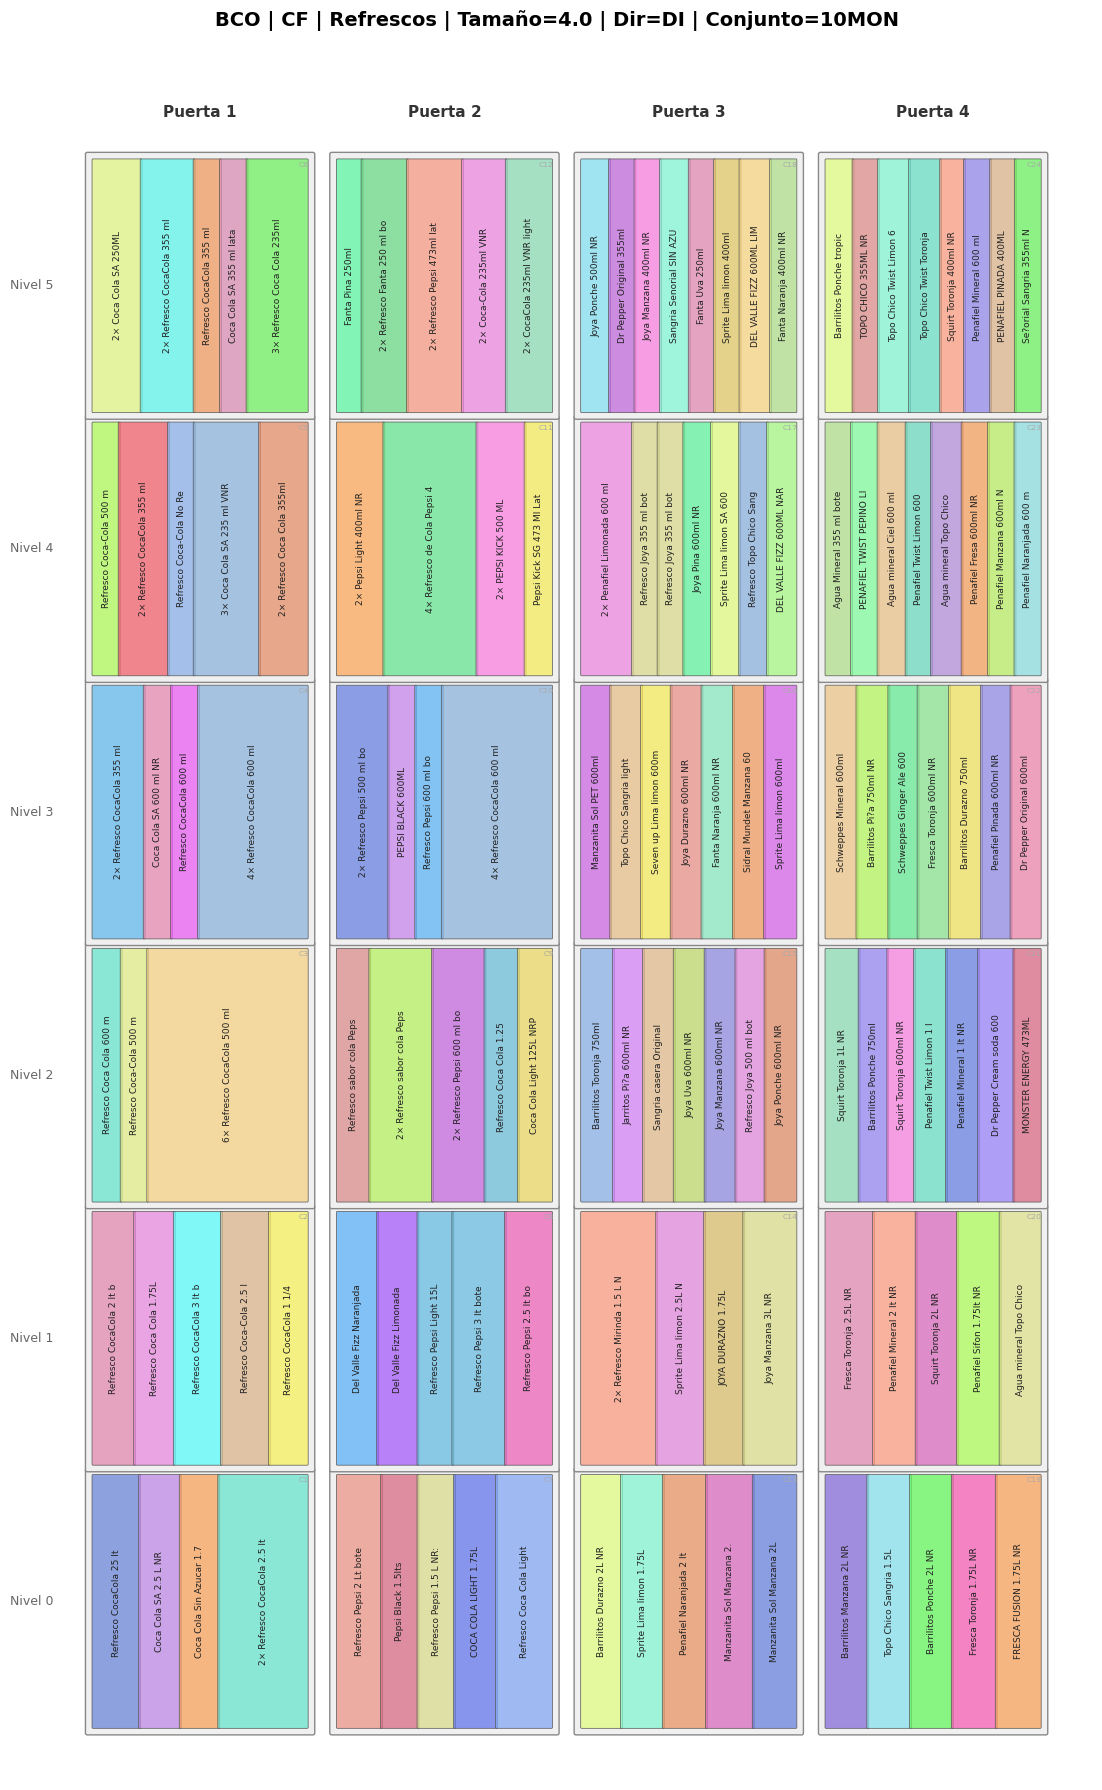

In [5]:
# %%
# =============================================================
# RUN EVALUATION
# =============================================================

import random

csv_path = "datos/ejemplo_planograma.csv"

print("Loading planograms...")
planograms = load_planograms(csv_path)

print("Building product catalog...")
catalog = build_product_catalog(csv_path)
print(f"  {len(catalog)} products in catalog")

# --- Mine rules from ALL planograms ---
print("\nMining placement rules from all planograms...")
rules = mine_placement_rules(planograms, catalog)
print(f"  Products with level data: {len(rules['level_probs'])}")
print(f"  Unique adjacency pairs: {len(rules['adjacencies'])}")

# --- Perturbation Test ---
print("\nRunning perturbation test...")
results = perturbation_test(planograms, catalog, rules)

# --- Summary by swap fraction ---
print("\n" + "=" * 90)
print("PERTURBATION TEST RESULTS")
print("=" * 90)

summary = results.groupby('source').agg({
        'level_rule_score': 'mean',
        'level_mode_accuracy': 'mean',
        'adjacency_hit_rate': 'mean',
        'adjacency_weighted': 'mean',
        'width_feasibility': 'mean',
        'height_level_corr': 'mean',
        'n_products_placed': 'mean',
    }).round(3)

print("\n" + summary.to_string())

# --- Detailed comparison ---
print("\n\nDetailed: original vs generated (20% swap) for each metric:")
orig = results[results['source'] == 'original']
gen20 = results[results['source'] == 'gen_20%_swap']

for col in ['level_rule_score', 'level_mode_accuracy',
                'adjacency_hit_rate', 'width_feasibility',
                'height_level_corr']:
    o_mean = orig[col].mean()
    g_mean = gen20[col].mean() if len(gen20) > 0 else 0
    delta = g_mean - o_mean
    print(f"  {col:<25} original={o_mean:.3f}  gen_20%={g_mean:.3f}  "
              f"delta={delta:+.3f}")

# --- Example: generate one with 20% swap and plot ---
print("\n\n--- Example Generation (20% swap on planogram 0) ---")
example = planograms[0]
orig_upcs = set()
for shelf in example.shelves.values():
    for p in shelf.products:
        orig_upcs.add(p.upc)

all_upcs = set()
for p in planograms:
    for shelf in p.shelves.values():
        for prod in shelf.products:
            all_upcs.add(prod.upc)

random.seed(42)
n_swap = int(len(orig_upcs) * 0.05)
to_remove = set(random.sample(list(orig_upcs), n_swap))
replacements = set(random.sample(
    list(all_upcs - orig_upcs), min(n_swap, len(all_upcs - orig_upcs))
    ))
target_upcs = (orig_upcs - to_remove) | replacements

print(f"Original: {len(orig_upcs)} products")
print(f"Removed: {len(to_remove)}, Added: {len(replacements)}")
print(f"Target: {len(target_upcs)} products")

match, overlap, total = find_best_match(
        target_upcs, example.tamano, planograms
    )
print(f"Best match: {match.title} (overlap: {overlap}/{total})")

generated = adapt_planogram(match, target_upcs, catalog)

# Evaluate both
orig_metrics = evaluate_rule_adherence(example, rules, catalog)
gen_metrics = evaluate_rule_adherence(generated, rules, catalog)

print(f"\n{'Metric':<25} {'Original':>10} {'Generated':>10}")
print("-" * 50)
for k in ['level_rule_score', 'level_mode_accuracy',
              'adjacency_hit_rate', 'width_feasibility',
              'height_level_corr', 'n_products_placed']:
    print(f"{k:<25} {orig_metrics[k]:>10.3f} {gen_metrics[k]:>10.3f}")

 # Plot
print("\nPlotting original...")
example.plot_planogram()
    

Plotting generated (20% swap)...


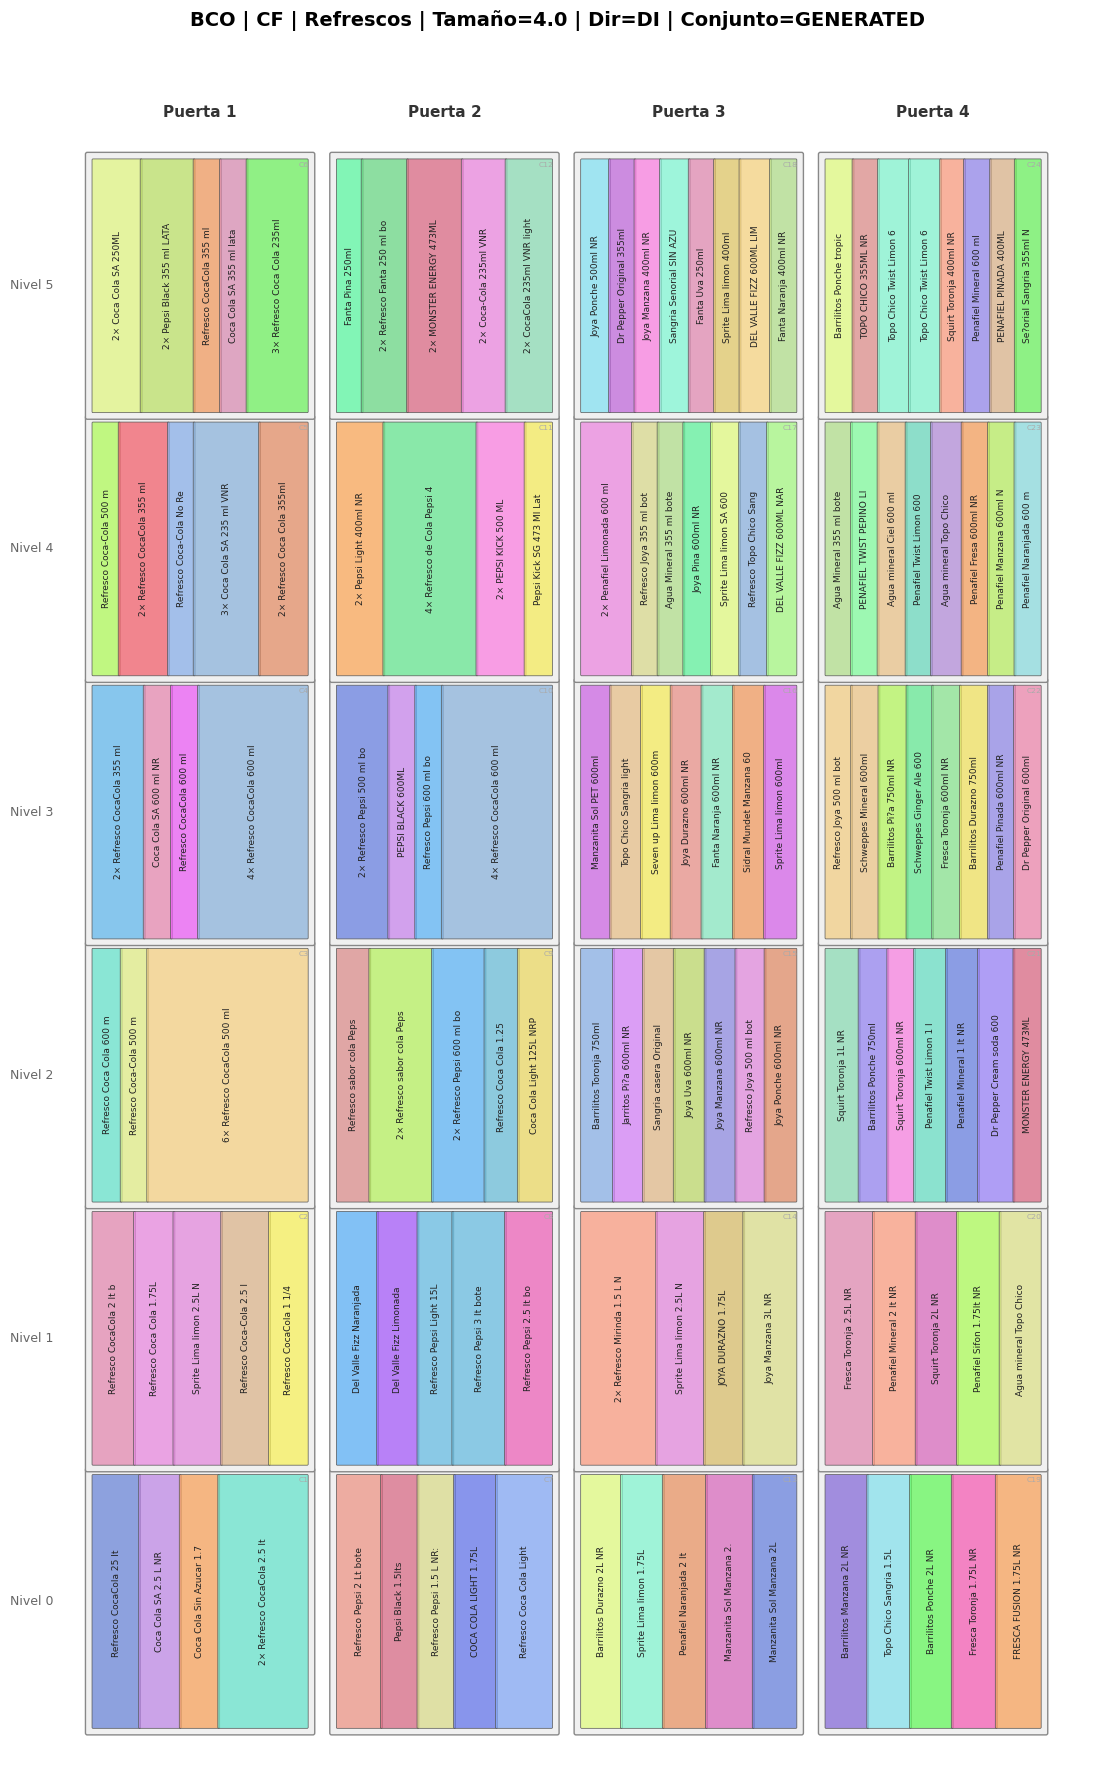

In [6]:
print("Plotting generated (20% swap)...")
generated.plot_planogram()